# LSTM model with full feature set (no PCA)

**Using downsampled features**

Author: Pete King

We repeat the LSTM test with the complete feature set, but using data downsampled to a weekly frequency.

In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)

import data_prep as dp
import models

# Global variables
DATA_FOLDER = 'data/downsample/W/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_pca_data.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_pca_data.csv'
TICKER = 'SPY'
SEQUENCE_LENGTH = 4  # No. observations in each input sequence to LSTM
BATCH_SIZE = 10  # For DataLoader

## I. Data Preparation

### Import and inspect financial data

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
# Select data (X) and label (y) -- use all features
data_cols, _ = dp.get_X_y_cols(train_df, returns=True)
label_col = [TICKER + '_vol_target']
train_df[data_cols].head(SEQUENCE_LENGTH)

,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hvol-4,...,XLB_vol-h,XLE_vol-h,XLF_vol-h,XLI_vol-h,XLK_vol-h,XLP_vol-h,XLRE_vol-h,XLU_vol-h,XLV_vol-h,XLY_vol-h
date,,,,,,,,,,,,,,,,,,,,,
2015-10-11,0.019764,-0.050772,-0.084379,-0.058875,-0.067594,-0.004911,-0.073287,-0.080450,-0.077928,0.101786,...,0.015475,0.019629,0.010939,0.015205,0.009424,0.010602,0.000741,0.008933,0.013072,0.009286
2015-10-18,0.140402,0.189389,0.111788,0.053244,0.164776,0.272643,0.162111,0.093840,0.019922,0.025007,...,0.005682,0.011585,0.011572,0.008683,0.005927,0.008371,0.009412,0.007745,0.012140,0.008376
2015-10-25,-0.057451,-0.121967,-0.112236,-0.080902,-0.105502,-0.113484,-0.093425,-0.139678,-0.127097,-0.027347,...,0.013638,0.013308,0.009617,0.012793,0.016336,0.009049,0.009390,0.009639,0.012871,0.006915
2015-11-01,-0.094880,-0.099647,-0.130287,-0.171168,-0.163077,-0.172389,-0.177274,-0.103115,-0.153335,-0.054839,...,0.007947,0.016180,0.012630,0.006200,0.008003,0.005718,0.003883,0.006223,0.009751,0.005900


In [3]:
val_df[label_col].head(SEQUENCE_LENGTH)

,SPY_vol_target
date,
2023-01-01,0.010604
2023-01-08,0.010161
2023-01-15,0.010400
2023-01-22,0.010328


### Scale Data

We represent each feature in a uniform range (0, 1).

In [4]:
scaler = MinMaxScaler()
# Take care to fit scaler only to training data
X_train = scaler.fit_transform(train_df[data_cols])
y_train = train_df[label_col].values
X_val = scaler.transform(val_df[data_cols])
y_val = val_df[label_col].values

## II. PyTorch Multivariate LSTM Model

### Create Datasets and DataLoaders

In [5]:
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32),
    y_train.astype(np.float32),
    sequence_length=SEQUENCE_LENGTH,
    target=False
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32),
    y_val.astype(np.float32),
    sequence_length=SEQUENCE_LENGTH,
    target=False
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [6]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([4, 100])
Shape of first training label: torch.Size([1])


In [7]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([10, 4, 100])
Shape of first batch of labels: torch.Size([10, 1])


In [8]:
print(y_0)

tensor([0.0092])


### Instantiate and train LSTM model

Here we increase the number of neurons in the hidden layer to allow the model to capture more complex relationships in the input data.  This could lead to overfitting if we set it too high.

In [9]:
# Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 32  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [10]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [11]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(100, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


#### Loss function and Optimizer


In [12]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [13]:
# Train and evaluate model
epochs = 1000
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
    all_preds.append(preds)
    if epochs <= 10:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')
    else:
        if (epoch + 1) % 100 == 0:
            print(f'Epoch {epoch + 1}')
            print(f'Training loss:   {loss_trn}')
            print(f'Validation loss: {loss_val}')

Training model over 1000 epochs...
Epoch 100
Training loss:   0.0005607679486274719
Validation loss: 0.0070389942266047
Epoch 200
Training loss:   0.0002459827810525894
Validation loss: 0.009427099488675594
Epoch 300
Training loss:   0.0029266951605677605
Validation loss: 0.017056167125701904
Epoch 400
Training loss:   0.0010823803022503853
Validation loss: 0.0031841422896832228
Epoch 500
Training loss:   5.7402998208999634e-05
Validation loss: 0.002718838630244136
Epoch 600
Training loss:   0.002345545217394829
Validation loss: 0.0024493462406098843
Epoch 700
Training loss:   0.0013072127476334572
Validation loss: 0.0013771923258900642
Epoch 800
Training loss:   0.0009120116010308266
Validation loss: 0.0012090837117284536
Epoch 900
Training loss:   0.002623346634209156
Validation loss: 0.008106296882033348
Epoch 1000
Training loss:   0.0003761760890483856
Validation loss: 0.0021636427845805883


## III. Analyze Results

### Plot of predictions vs labels (final epoch)


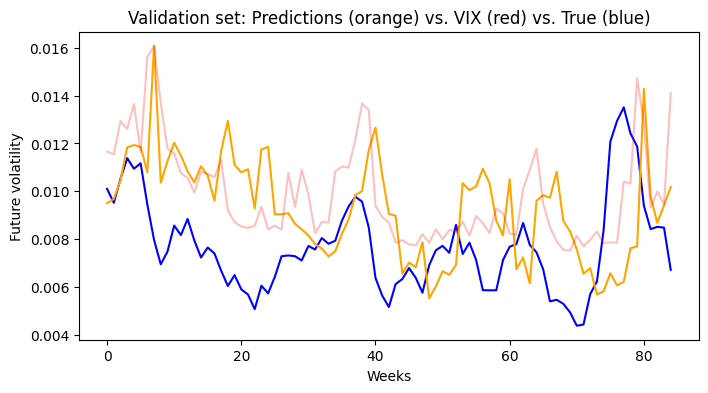

In [14]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]
# The VIX estimates annualized volatility for the next 30 days
vix = val_df['^VIX'].values[SEQUENCE_LENGTH:] / np.sqrt(252) / 100

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. VIX (red) vs. True (blue)')
ax.set_ylabel('Future volatility')
ax.set_xlabel('Weeks')
ax.plot(x, labels, color='blue')
ax.plot(x, preds, color='orange')
ax.plot(x, vix, color='red', alpha=0.25)

The full set of features appears to have introduced too much noise -- the model behaves much less consistently than in the case with limited input.

In [15]:
metrics = {
    'MAE': mean_absolute_error,
    'R2': r2_score,
}
# Out-of-sample R-squared compares model performance to baseline (VIX)
r2_oos = 1 - (
    mean_absolute_error(labels, preds)
    / mean_absolute_error(labels, vix)
)
# Display results
for metric, scorer in metrics.items():
    print(f'Model {metric}: {scorer(labels, preds):.5f}')
    print(f'VIX {metric}:   {scorer(labels, vix):.5f}')
    print('---')
print(f'Model R2-OOS: {r2_oos:.2f}')

Model MAE: 0.00265
VIX MAE:   0.00255
---
Model R2: -1.94705
VIX R2:   -1.38117
---
Model R2-OOS: -0.04


The negative value for out-of-sample R-squared indicatest that with the full feature set, our model performed worse than the baseline.